# BRFSS Model

---

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import glob
import os
import re
import joblib
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.feature_selection import SelectFromModel

from sklearn.linear_model import Ridge, Lasso, LinearRegression, PoissonRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
# from tabpfn import TabPFNRegressor

## Load

In [3]:
# ============================================================
# BRFSS Model Training Notebook
# Loads preprocessed data and trains multiple models
# ============================================================

# ============================================================
# Configuration
# ============================================================
n_samples = 19999
n_years = 7
target = "MENTHLTH"
random_state = 42
test_size = 0.20
n_important_features = 20
dataset = f"{n_years}-years_{n_samples}-samples_{n_important_features}-features.csv"
dataset_path = '/content/sample_data/7-years_19999-samples_20-features.csv'

if not os.path.exists(dataset_path):
    raise FileNotFoundError(
        f"Preprocessed file not found: {dataset_path}\n"
        f"Please run the preprocessing notebook first to generate this file."
    )

# Load the data
df = pd.read_csv(dataset_path)
print(f"Loaded {len(df)} rows, {len(df.columns)} columns from '{dataset}'")

# Extract actual number of years from the data
if 'YEAR' in df.columns:
    actual_years = sorted(df['YEAR'].unique())
    print(f"Years included: {actual_years}")

# ============================================================
# Prepare Features and Target
# ============================================================

# Ensure target is in the dataframe
if target not in df.columns:
    raise ValueError(f"Target '{target}' not found in dataframe")

# Remove ID columns
drop_cols = [
    target,
    "SEQNO",
    "_PSU",
    "_STSTR",
    "IDATE",
    "IMONTH",
    "IDAY",
    "IYEAR"
]

X = df.drop(columns=[c for c in drop_cols if c in df.columns], errors="ignore")

# Remove leakage columns
if target == "MENTHLTH":
    leakage = ["_MENT14D", "POORHLTH"]
elif target == "PHYSHLTH":
    leakage = ["_PHYS14D"]
elif target == "GENHLTH":
    leakage = ["_RFHLTH"]
elif target == "LSATISFY":
    leakage = []
else:
    leakage = []

X = X.drop(columns=[c for c in leakage if c in X.columns], errors="ignore")

# ============================================================
# OPTIONAL: Drop survey design variables (to avoid leakage)
# These are weighting variables, not health predictors
# ============================================================
survey_design_vars = ['_LLCPWT', '_LLCPWT2', '_STRWT', '_WT2RAKE', '_RAWRAKE']
X = X.drop(columns=[c for c in survey_design_vars if c in X.columns], errors="ignore")
print(f"Dropped survey design variables: {[c for c in survey_design_vars if c in X.columns]}")

# Store y (target)
y = df[target]

print(f"Samples: {y.shape[0]}\nFeatures: {X.shape[1]}")

# ============================================================
# Train-Test Split
# ============================================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=test_size,
    random_state=random_state
)

print(f"\nTraining set: {len(X_train)} samples")
print(f"Test set: {len(X_test)} samples")

# ============================================================
# Feature Scaling (for linear models)
# ============================================================
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Loaded 19999 rows, 21 columns from '7-years_19999-samples_20-features.csv'
Years included: [np.float64(2018.0), np.float64(2019.0), np.float64(2020.0), np.float64(2021.0), np.float64(2022.0), np.float64(2023.0), np.float64(2024.0)]
Dropped survey design variables: []
Samples: 19999
Features: 20

Training set: 15999 samples
Test set: 4000 samples


In [4]:
print(f"{int(len(np.where(y == 0)[0]) / len(y) * 100)}% of targets are 0")

63% of targets are 0


---

## Model

### Traditional tree-based models


MODEL TRAINING AND EVALUATION

Training: XGBoost
Hyperparameter tuning with RandomizedSearchCV...
Best parameters: {'colsample_bytree': 0.7, 'learning_rate': 0.02, 'max_depth': 3, 'min_child_weight': 3, 'n_estimators': 650, 'reg_alpha': 0.1, 'reg_lambda': 0.1, 'subsample': 0.7}
Cross-Validation MAE: 4.3157 (+/- 0.0522)

Test Set Performance:
  MAE:  4.4033
  RMSE: 7.0942
  R²:   0.2856

Training: Random Forest
Hyperparameter tuning with RandomizedSearchCV...
Best parameters: {'max_depth': 10, 'min_samples_leaf': 6, 'min_samples_split': 2, 'n_estimators': 700}
Cross-Validation MAE: 4.3906 (+/- 0.0472)

Test Set Performance:
  MAE:  4.4747
  RMSE: 7.1672
  R²:   0.2708

Training: LightGBM
Hyperparameter tuning with RandomizedSearchCV...
Best parameters: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 300}
Cross-Validation MAE: 4.4242 (+/- 0.0548)

Test Set Performance:
  MAE:  4.4829
  RMSE: 7.1494
  R²:   0.2744

Training: Ridge
Hyperparameter tuning with RandomizedSearchCV...


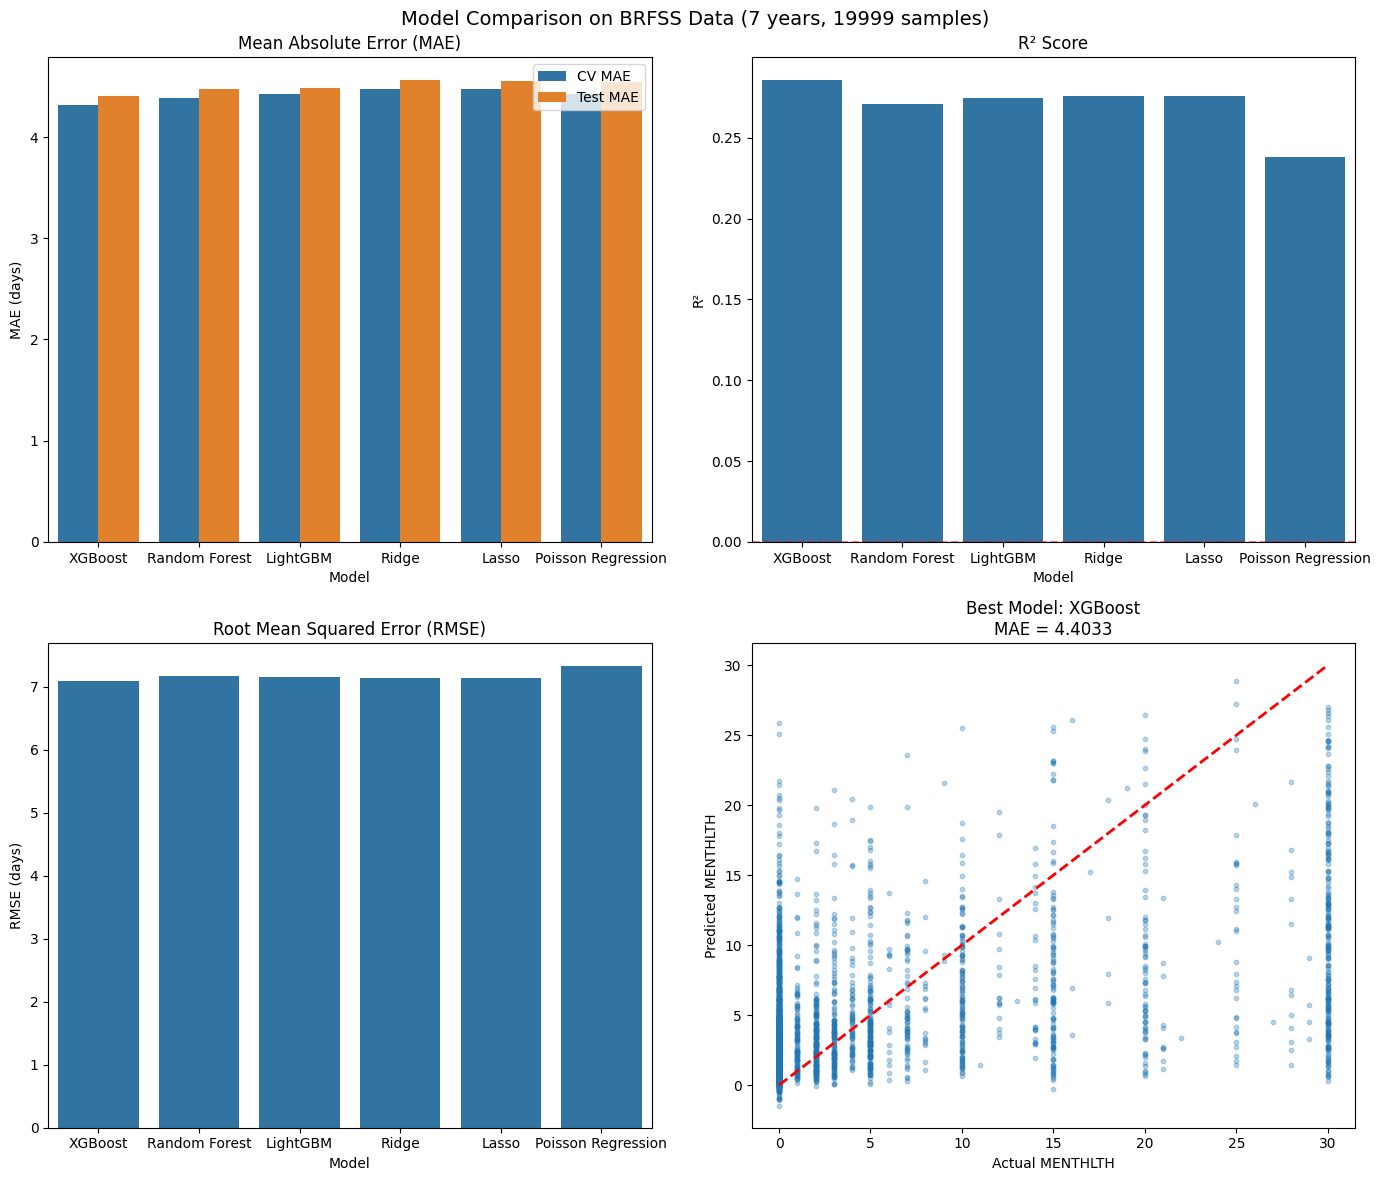


FEATURE IMPORTANCE (Top 15)

XGBoost Feature Importances:
 Feature  Importance
  DECIDE    0.397235
_PHYS14D    0.169512
PHYSHLTH    0.065742
DIFFALON    0.056262
 GENHLTH    0.046306
  _AGE80    0.042675
RENTHOM1    0.028546
_SMOKER3    0.026972
 QSTLANG    0.023910
 MARITAL    0.022652
_ASTHMS1    0.018747
  QSTVER    0.012773
 _EDUCAG    0.012382
  FMONTH    0.011813
   _BMI5    0.011809

Random Forest Feature Importances:
 Feature  Importance
  DECIDE    0.318433
PHYSHLTH    0.155830
  _AGE80    0.122741
   _BMI5    0.069739
  _STATE    0.053497
 GENHLTH    0.047673
  FMONTH    0.029587
    YEAR    0.026467
_SMOKER3    0.024618
 MARITAL    0.024425
DIFFALON    0.018744
 _EDUCAG    0.018478
  QSTVER    0.017432
_IMPRACE    0.015816
RENTHOM1    0.013247

LightGBM Feature Importances:
 Feature  Importance
   _BMI5         321
  _AGE80         290
PHYSHLTH         214
 GENHLTH         175
  _STATE         116
  DECIDE          96
  FMONTH          78
RENTHOM1          74
 HHADULT     

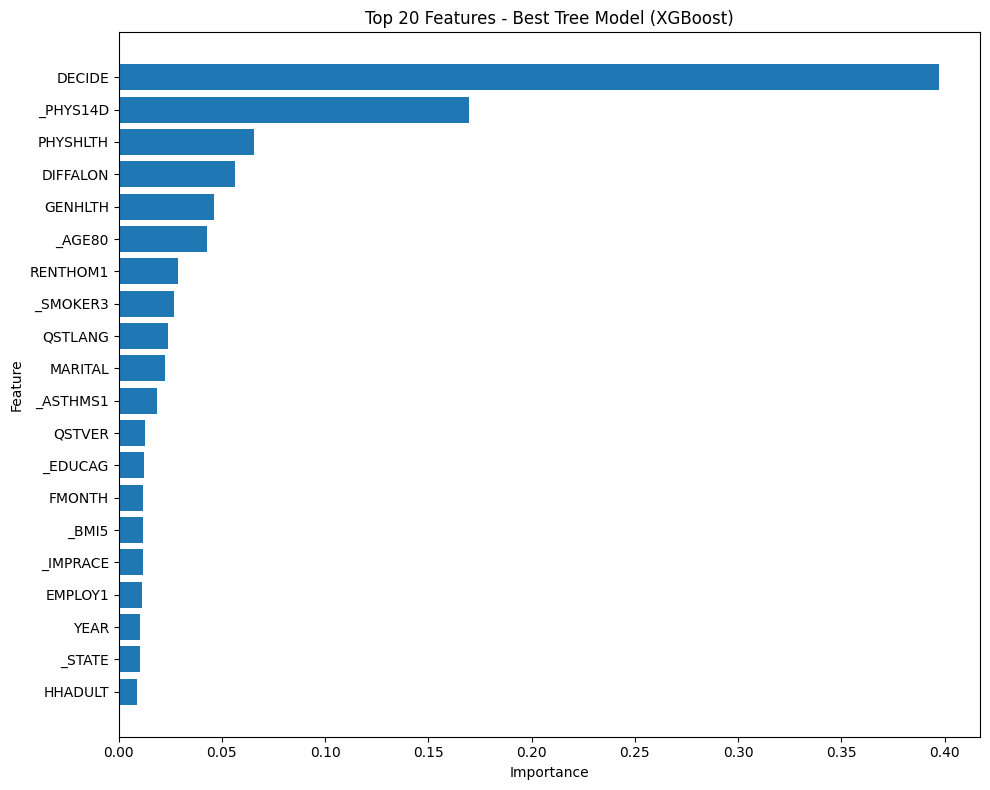


TRAINING COMPLETE


In [5]:
models = {
    'XGBoost': {
        'model': XGBRegressor(random_state=random_state, n_jobs=-1, verbosity=0),
        'use_scaled': False,
        'params': {
            'n_estimators': [650, 700],
            'max_depth': [2, 3],
            'learning_rate': [0.02, 0.25],
            'subsample': [0.7, 0.8],
            'colsample_bytree': [0.7],
            'min_child_weight': [3],
            'reg_alpha': [0.1],
            'reg_lambda': [0.1]
        }
    },

    'Random Forest': {
        'model': RandomForestRegressor(random_state=random_state, n_jobs=-1),
        'use_scaled': False,
        'params': {
            'n_estimators': [700, 750],
            'max_depth': [8, 10],
            'min_samples_split': [2],
            'min_samples_leaf': [6]
        }
    },
    'LightGBM': {
        'model': LGBMRegressor(random_state=random_state, n_jobs=-1, verbose=-1),
        'use_scaled': False,
        'params': {
            'n_estimators': [300, 500, 700],
            'max_depth': [3, 5, 7, -1],
            'learning_rate': [0.02, 0.05, 0.1],
        }
    },
    'Ridge': {
        'model': Ridge(random_state=random_state),
        'use_scaled': True,
        'params': {
            'alpha': [0.001, 0.005, 0.01, 0.05, 0.1, 0.5, 1.0, 5.0, 10.0, 50.0]
        }
    },
    'Lasso': {
        'model': Lasso(random_state=random_state, max_iter=10000),
        'use_scaled': True,
        'params': {
            'alpha': [0.0001, 0.0005, 0.001, 0.005, 0.01, 0.05, 0.1, 0.5, 1.0]
        }
    },
    'Poisson Regression': {
        'model': PoissonRegressor(max_iter=1000, alpha=0),
        'use_scaled': True,
        'params': {
            'alpha': [0, 0.001, 0.01, 0.1, 0.5, 1.0]
        }
    }
}

# ============================================================
# Train, Tune, and Evaluate Each Model
# ============================================================

results = []
best_models = {}

print("\n" + "="*70)
print("MODEL TRAINING AND EVALUATION")
print("="*70)

for name, config in models.items():
    print(f"\n{'='*60}")
    print(f"Training: {name}")
    print('='*60)

    # Select features
    if config['use_scaled']:
        X_train_use = X_train_scaled
        X_test_use = X_test_scaled
    else:
        X_train_use = X_train
        X_test_use = X_test

    # Use RandomizedSearchCV for large grids (faster)
    print("Hyperparameter tuning with RandomizedSearchCV...")

    if len(config['params']) > 0:
        # Random search for large grids
        if len(config['params']) > 10:
            random_search = RandomizedSearchCV(
                estimator=config['model'],
                param_distributions=config['params'],
                n_iter=20,  # Try 20 random combinations
                cv=5,
                scoring='neg_mean_absolute_error',
                n_jobs=-1,
                verbose=0,
                random_state=random_state
            )
            random_search.fit(X_train_use, y_train)
            best_model = random_search.best_estimator_
            best_params = random_search.best_params_
        else:
            # Grid search for smaller grids
            grid_search = GridSearchCV(
                estimator=config['model'],
                param_grid=config['params'],
                cv=5,
                scoring='neg_mean_absolute_error',
                n_jobs=-1,
                verbose=0
            )
            grid_search.fit(X_train_use, y_train)
            best_model = grid_search.best_estimator_
            best_params = grid_search.best_params_
    else:
        # No hyperparameters to tune
        best_model = config['model']
        best_params = {}
        best_model.fit(X_train_use, y_train)

    print(f"Best parameters: {best_params}")

    # Cross-validation score
    cv_scores = cross_val_score(
        best_model, X_train_use, y_train,
        cv=5, scoring='neg_mean_absolute_error'
    )
    cv_mae = -cv_scores.mean()
    print(f"Cross-Validation MAE: {cv_mae:.4f} (+/- {cv_scores.std():.4f})")

    # Predictions on test set
    y_pred = best_model.predict(X_test_use)

    # Evaluation metrics
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)

    print(f"\nTest Set Performance:")
    print(f"  MAE:  {mae:.4f}")
    print(f"  RMSE: {rmse:.4f}")
    print(f"  R²:   {r2:.4f}")

    # Store results
    result = {
        'Model': name,
        'Best Params': best_params,
        'CV MAE': cv_mae,
        'Test MAE': mae,
        'Test RMSE': rmse,
        'Test R²': r2,
        'Model Object': best_model
    }
    results.append(result)
    best_models[name] = best_model

# ============================================================
# Results Summary
# ============================================================
print("\n" + "="*70)
print("RESULTS SUMMARY")
print("="*70)

results_df = pd.DataFrame([
    {
        'Model': r['Model'],
        'CV MAE': r['CV MAE'],
        'Test MAE': r['Test MAE'],
        'Test RMSE': r['Test RMSE'],
        'Test R²': r['Test R²']
    }
    for r in results
])

print(results_df.to_string(index=False))

# Sort by Test MAE
best_model = min(results, key=lambda x: x['Test MAE'])
print(f"\nBest Model: {best_model['Model']} (MAE: {best_model['Test MAE']:.4f})")

# ============================================================
# Visualize Results
# ============================================================
os.makedirs('plots', exist_ok=True)

fig, axes = plt.subplots(2, 2, figsize=(14, 12))
fig.suptitle(f'Model Comparison on BRFSS Data ({n_years} years, {len(df)} samples)', fontsize=14)

# Plot 1: MAE Comparison
ax1 = axes[0, 0]
metrics = results_df.melt(
    id_vars=['Model'],
    value_vars=['CV MAE', 'Test MAE'],
    var_name='Metric', value_name='MAE'
)
sns.barplot(data=metrics, x='Model', y='MAE', hue='Metric', ax=ax1)
ax1.set_title('Mean Absolute Error (MAE)')
ax1.set_ylabel('MAE (days)')
ax1.legend()

# Plot 2: R² Comparison
ax2 = axes[0, 1]
sns.barplot(data=results_df, x='Model', y='Test R²', ax=ax2)
ax2.set_title('R² Score')
ax2.set_ylabel('R²')
ax2.axhline(y=0, color='red', linestyle='--', alpha=0.5)

# Plot 3: RMSE Comparison
ax3 = axes[1, 0]
sns.barplot(data=results_df, x='Model', y='Test RMSE', ax=ax3)
ax3.set_title('Root Mean Squared Error (RMSE)')
ax3.set_ylabel('RMSE (days)')

# Plot 4: Actual vs Predicted for Best Model
best_model_obj = best_model['Model Object']
best_model_name = best_model['Model']

if models[best_model_name]['use_scaled']:
    y_pred_best = best_model_obj.predict(X_test_scaled)
else:
    y_pred_best = best_model_obj.predict(X_test)

ax4 = axes[1, 1]
ax4.scatter(y_test, y_pred_best, alpha=0.3, s=10)
ax4.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
ax4.set_xlabel('Actual MENTHLTH')
ax4.set_ylabel('Predicted MENTHLTH')
ax4.set_title(f'Best Model: {best_model_name}\nMAE = {best_model["Test MAE"]:.4f}')

plt.tight_layout()
plt.savefig('plots/model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# ============================================================
# Feature Importance (for tree-based models)
# ============================================================
print("\n" + "="*70)
print("FEATURE IMPORTANCE (Top 15)")
print("="*70)

for r in results:
    model = r['Model Object']
    model_name = r['Model']
    if hasattr(model, 'feature_importances_'):
        print(f"\n{model_name} Feature Importances:")
        importances = model.feature_importances_
        feature_imp = pd.DataFrame({
            'Feature': X.columns,
            'Importance': importances
        }).sort_values('Importance', ascending=False).head(15)
        print(feature_imp.to_string(index=False))
    elif hasattr(model, 'coef_'):
        print(f"\n{model_name} Coefficients (Top 15 absolute):")
        coefs = model.coef_.flatten() if len(model.coef_.shape) > 1 else model.coef_
        coef_imp = pd.DataFrame({
            'Feature': X.columns,
            'Coefficient': coefs
        })
        coef_imp['Abs'] = np.abs(coef_imp['Coefficient'])
        coef_imp = coef_imp.sort_values('Abs', ascending=False).head(15)
        print(coef_imp[['Feature', 'Coefficient']].to_string(index=False))
    else:
        print(f"\n{model_name} does not provide feature importance.")

# ============================================================
# Save Best Model and Results
# ============================================================
os.makedirs('models', exist_ok=True)

# Save best model
best_model = min(results, key=lambda x: x['Test MAE'])
joblib.dump(best_model['Model Object'], f'models/best_model_{best_model["Model"]}.pkl')
print(f"\nBest model ({best_model['Model']}) saved to models/best_model_{best_model['Model']}.pkl")

# Save scaler
if any(r['Model'] in ['Ridge', 'Lasso', 'Poisson Regression'] for r in results):
    joblib.dump(scaler, 'models/scaler.pkl')
    print("Scaler saved to models/scaler.pkl")

# Save results to CSV
results_df.to_csv('models/model_results.csv', index=False)
print("Results saved to models/model_results.csv")

# ============================================================
# Feature Importance Visualization (Top 20) - for best tree model
# ============================================================
best_tree_model = next((r for r in results if hasattr(r['Model Object'], 'feature_importances_')), None)

if best_tree_model:
    importances = best_tree_model['Model Object'].feature_importances_
    feature_imp = pd.DataFrame({
        'Feature': X.columns,
        'Importance': importances
    }).sort_values('Importance', ascending=True).tail(20)

    plt.figure(figsize=(10, 8))
    plt.barh(feature_imp['Feature'], feature_imp['Importance'])
    plt.xlabel('Importance')
    plt.ylabel('Feature')
    plt.title(f'Top 20 Features - Best Tree Model ({best_tree_model["Model"]})')
    plt.tight_layout()
    plt.savefig('plots/best_model_feature_importance.png', dpi=150, bbox_inches='tight')
    plt.show()

print("\n" + "="*70)
print("TRAINING COMPLETE")
print("="*70)

---

### Deep Learning Models

In [ ]:
# Assume your data is loaded into X and y
# X = your feature DataFrame
# y = your target Series

# 1. Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 2. Initialize and Train TabPFN
# TabPFN works best with up to ~10,000 samples. For 20,000, it's still effective.
model = TabPFNRegressor(
    device='cpu',  # Use 'cuda' if you have a GPU
    random_state=42
)

# TabPFN requires the data to be in numpy arrays
model.fit(X_train.values, y_train.values)

# 3. Predict and Evaluate
y_pred = model.predict(X_test.values)

mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"TabPFN Test MAE: {mae:.4f}")
print(f"TabPFN Test R²:  {r2:.4f}")

# 4. Feature Importance (TabPFN can provide this)
# feature_importances = model.feature_importances_

TabPFNLicenseError: TabPFN requires a one-time license acceptance to download
model weights for local inference, but no interactive terminal
is available.

To authenticate in a non-interactive environment:
  1. Open https://ux.priorlabs.ai in a browser and log in (or register)
  2. Accept the license on the Licenses tab
  3. Copy your API Key from https://ux.priorlabs.ai/account
  4. Set the environment variable: export TABPFN_TOKEN="<your-api-key>"
     or in Python (before calling .fit()): import os; os.environ["TABPFN_TOKEN"] = "<your-api-key>"

---